# Decision Tree

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

# Decision trees split on raw thresholds — log transforms and clipping are not needed.
# StandardScaler is passed for interface consistency but does not affect tree behaviour.
X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Train shape: (4455, 17)
Test shape:  (1114, 17)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (698, 17)
Class weights: {np.int64(0): np.float64(0.778149386845039), np.int64(1): np.float64(1.1633333333333333), np.int64(2): np.float64(1.169179229480737)}

Outputs ready for modeling:
  X_train_bal       → (698, 17) (balanced, scaled)
  y_train_bal       → 698 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

grid_dt = run_grid_search(
    DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42),
    param_grid,
    X_train_bal,
    y_train_bal,
)
dt = grid_dt.best_estimator_

y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt  = dt.predict_proba(X_test_scaled)

print("Decision Tree training complete.")
print(f"Best max_depth:        {grid_dt.best_params_['max_depth']}")
print(f"Best min_samples_leaf: {grid_dt.best_params_['min_samples_leaf']}")
print(f"Best criterion:        {grid_dt.best_params_['criterion']}")
print(f"Best CV F1 Macro:      {grid_dt.best_score_:.4f}")
print(f"Actual tree depth:     {dt.get_depth()}")
print(f"Number of leaves:      {dt.get_n_leaves()}")

Decision Tree training complete.
Best max_depth:        5
Best min_samples_leaf: 1
Best criterion:        entropy
Best CV F1 Macro:      0.9823
Actual tree depth:     5
Number of leaves:      11


## Modeling
### DIAGNOSTIC PLOT 1: Feature Importances

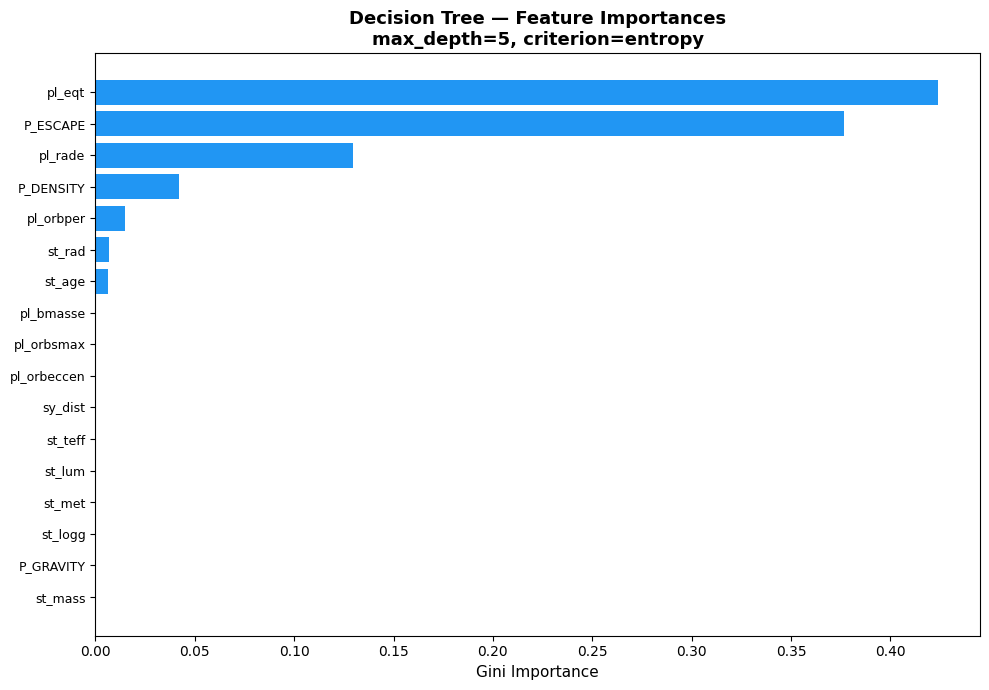

↑ Gini importance = total reduction in impurity weighted by the fraction of samples reaching each split.
  A single dominant feature suggests the tree found a strong global threshold.
  Many near-zero features = the tree ignored them entirely.


In [4]:
importances = dt.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [colors[0]] * len(FEATURES)
ax.barh(
    range(len(FEATURES)),
    importances[sorted_idx],
    color="#2196F3", edgecolor="none",
)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FEATURES[i] for i in sorted_idx], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Gini Importance", fontsize=11)
ax.set_title(
    f"Decision Tree — Feature Importances\n"
    f"max_depth={dt.get_depth()}, criterion={dt.criterion}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_plot("dt_feature_importances")
plt.show()

print("↑ Gini importance = total reduction in impurity weighted by the fraction of samples reaching each split.")
print("  A single dominant feature suggests the tree found a strong global threshold.")
print("  Many near-zero features = the tree ignored them entirely.")

### DIAGNOSTIC PLOT 2: Depth vs CV F1 Macro

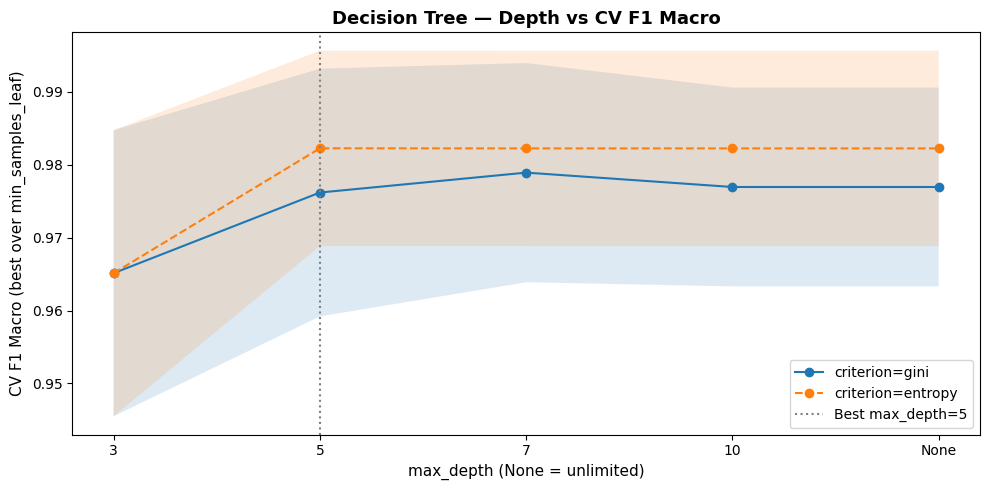

↑ Each point = best score across all min_samples_leaf values at that depth.
  Shallow trees underfit; deep trees overfit the balanced training set.
  None = no depth limit — the tree grows until leaves are pure.


In [5]:
results_df = pd.DataFrame(grid_dt.cv_results_)
depth_labels = [str(d) if d is not None else "None" for d in [3, 5, 7, 10, None]]
depth_vals   = [3, 5, 7, 10, None]

fig, ax = plt.subplots(figsize=(10, 5))
for criterion, ls in [("gini", "-"), ("entropy", "--")]:
    means, stds = [], []
    for d in depth_vals:
        mask = (
            (results_df["param_criterion"] == criterion) &
            (results_df["param_max_depth"].apply(lambda x: x == d))
        )
        sub = results_df[mask]
        means.append(sub["mean_test_score"].max())
        stds.append(sub.loc[sub["mean_test_score"].idxmax(), "std_test_score"])
    means, stds = np.array(means), np.array(stds)
    ax.plot(range(len(depth_labels)), means, marker="o", ls=ls, label=f"criterion={criterion}")
    ax.fill_between(range(len(depth_labels)), means - stds, means + stds, alpha=0.15)

best_d = str(grid_dt.best_params_["max_depth"])
best_x = depth_labels.index(best_d)
ax.axvline(best_x, color="gray", ls=":", lw=1.5, label=f"Best max_depth={best_d}")
ax.set_xticks(range(len(depth_labels)))
ax.set_xticklabels(depth_labels, fontsize=10)
ax.set_xlabel("max_depth (None = unlimited)", fontsize=11)
ax.set_ylabel("CV F1 Macro (best over min_samples_leaf)", fontsize=11)
ax.set_title("Decision Tree — Depth vs CV F1 Macro", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("dt_depth_sensitivity")
plt.show()

print("↑ Each point = best score across all min_samples_leaf values at that depth.")
print("  Shallow trees underfit; deep trees overfit the balanced training set.")
print("  None = no depth limit — the tree grows until leaves are pure.")

### DIAGNOSTIC PLOT 3: Tree Structure (depth ≤ 5)

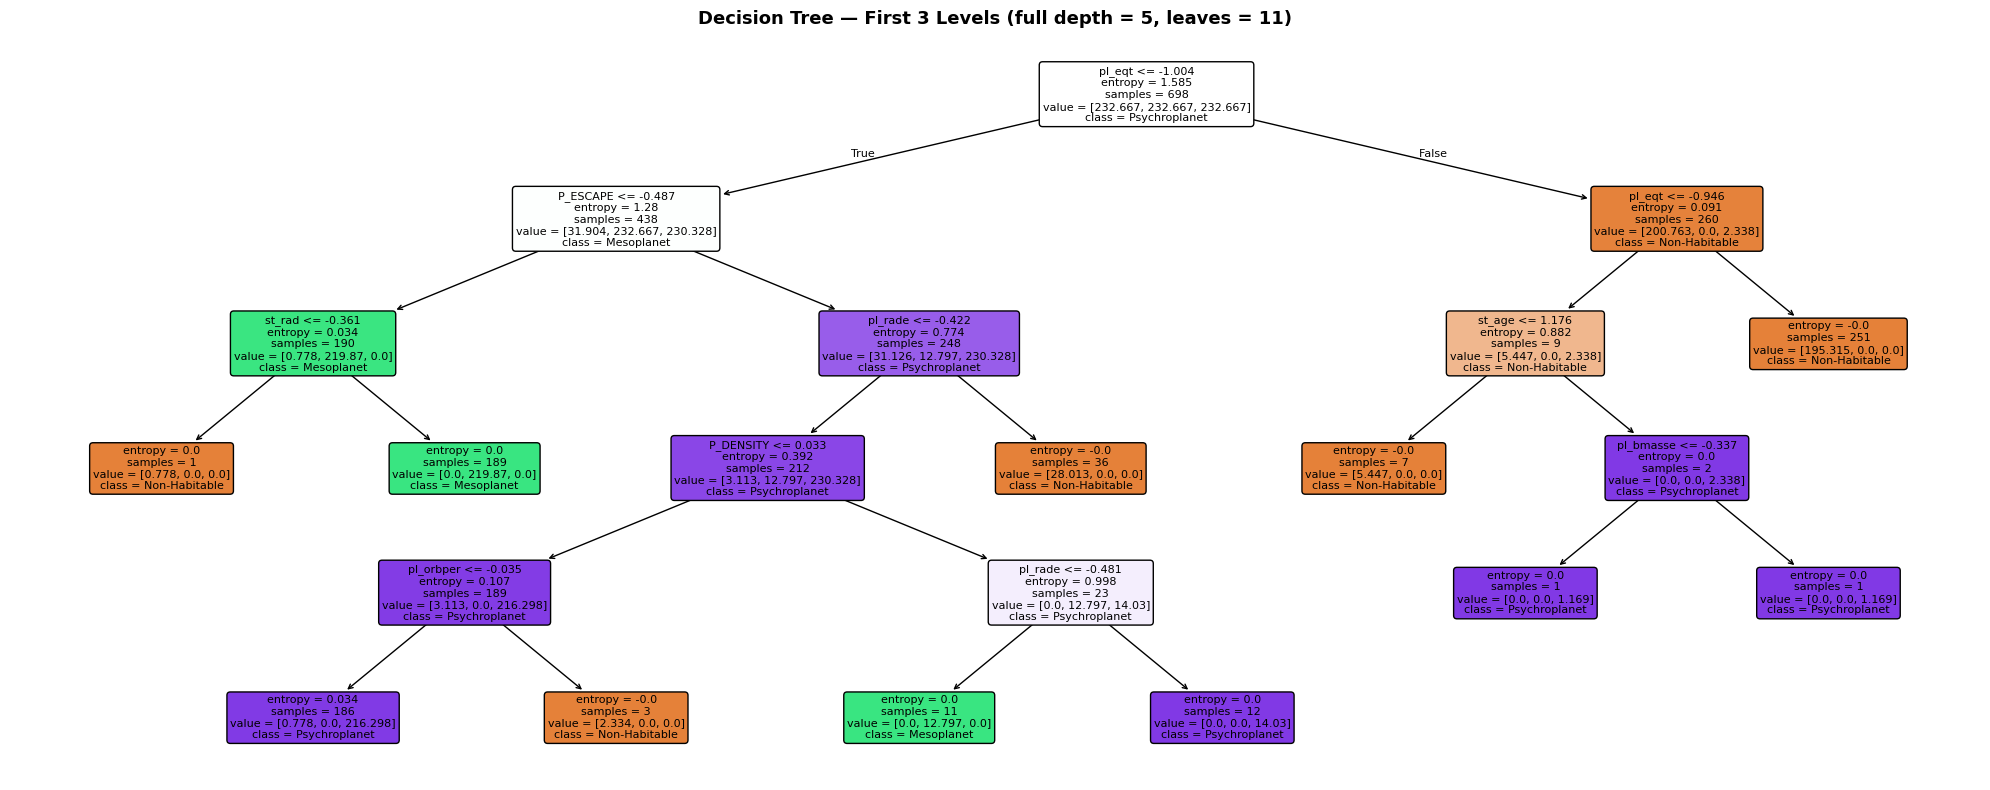

↑ Each node shows: split feature/threshold, Gini impurity, sample count, class distribution.
  Colour intensity = class purity (darker = more confident split).
  Only the first 3 levels shown — the full tree has 5 levels and 11 leaves.


In [9]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    max_depth=5,
    feature_names=FEATURES,
    class_names=class_names,
    filled=True,
    impurity=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title(
    f"Decision Tree — First 3 Levels (full depth = {dt.get_depth()}, leaves = {dt.get_n_leaves()})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_plot("dt_tree_structure")
plt.show()

print("↑ Each node shows: split feature/threshold, Gini impurity, sample count, class distribution.")
print("  Colour intensity = class purity (darker = more confident split).")
print(f"  Only the first 3 levels shown — the full tree has {dt.get_depth()} levels and {dt.get_n_leaves()} leaves.")

## Metrics
### Classification Report + F1 Scores

DT — Classification Report
               precision    recall  f1-score   support

Non-Habitable     0.9991    0.9936    0.9964      1100
   Mesoplanet     1.0000    1.0000    1.0000         6
Psychroplanet     0.5000    0.8750    0.6364         8

     accuracy                         0.9928      1114
    macro avg     0.8330    0.9562    0.8776      1114
 weighted avg     0.9955    0.9928    0.9938      1114

F1 Macro:    0.8776
F1 Weighted: 0.9938

5-Fold CV F1 Macro: 0.9693 ± 0.0228
F1 Macro:    0.8776
F1 Weighted: 0.9938


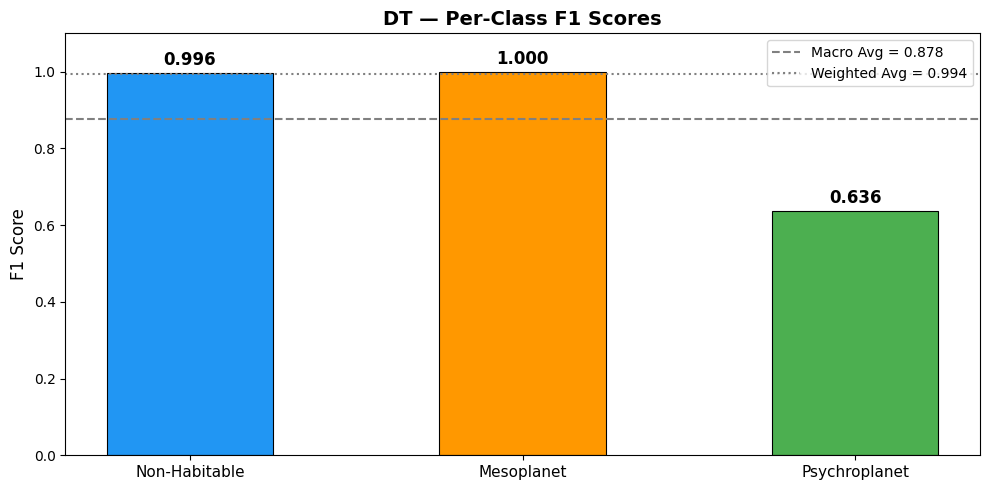

In [7]:
print_classification_report(y_test, y_pred_dt, "DT")

f1_macro_dt, f1_weighted_dt, _ = compute_f1_scores(y_test, y_pred_dt)

cv_scores_dt = run_stratified_cv(dt, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_dt, "DT")

### Confusion Matrices (Counts + Normalized)

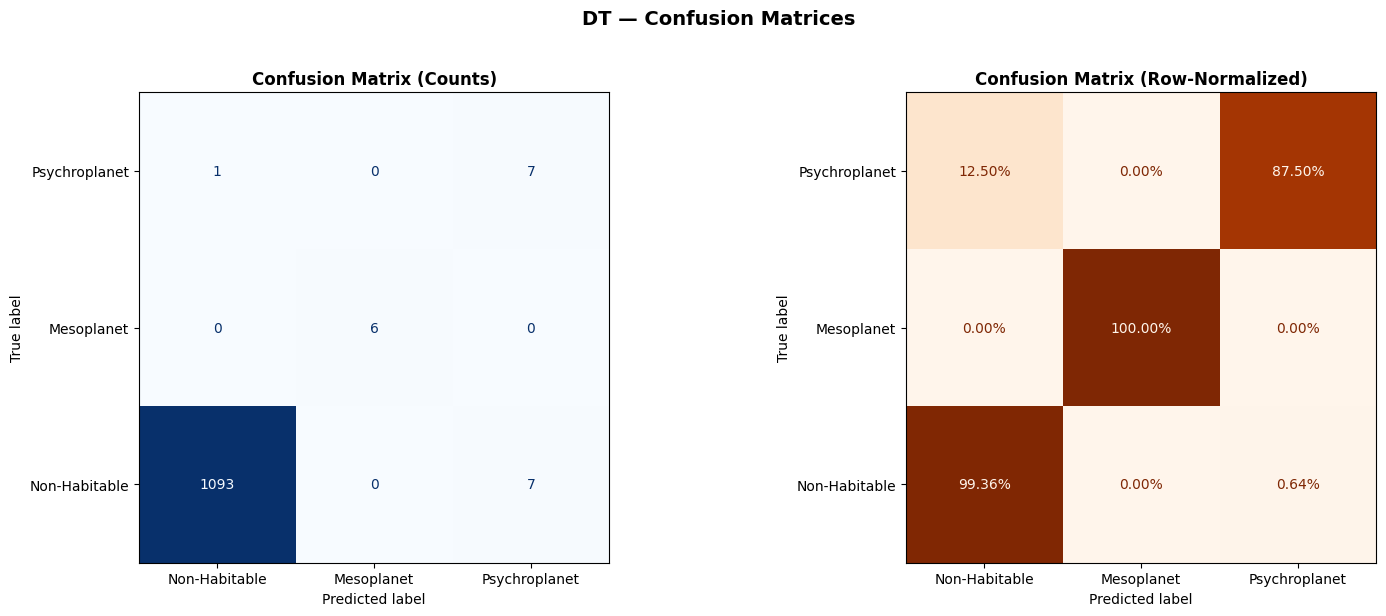

Key error patterns:
  Non-Habitable → predicted Psychroplanet: 7 (0.6% of true Non-Habitable)
  Psychroplanet → predicted Non-Habitable: 1 (12.5% of true Psychroplanet)


In [8]:
plot_confusion_matrices(y_test, y_pred_dt, "DT")
print_error_patterns(y_test, y_pred_dt)

## Interpretation: